Found 1201 images belonging to 3 classes.
Found 299 images belonging to 3 classes.
Class indices: {'Person 1': 0, 'Person 2': 1, 'Person 3': 2}
Epoch 1/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 283s 7s/step - accuracy: 0.8343 - loss: 0.4654 - val_accuracy: 0.9431 - val_loss: 0.0871
Epoch 2/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9975 - loss: 0.0117 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 3/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9983 - loss: 0.0061 - val_accuracy: 1.0000 - val_loss: 0.0392
Epoch 4/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9975 - loss: 0.0060 - val_accuracy: 1.0000 - val_loss: 2.3884e-05
Epoch 5/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.9983 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 1.1923e-05
Epoch 6/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.9983 - loss: 0.0041 - val_accuracy: 0.8763 - val_loss: 0.2326
Epoch 7/15
38/38 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.9992 - loss: 0.0048 - val_a

Model saved successfully as face_recognition_cnn.h5
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 313ms/step - accuracy: 0.9465 - loss: 0.2329

Test Loss: 0.23285724222660065
Test Accuracy: 0.9464883208274841
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 319ms/step

Confusion Matrix:
[[ 84   0  16]
 [  0 100   0]
 [  0   0  99]]

Classification Report:
              precision    recall  f1-score   support

    Person 1       1.00      0.84      0.91       100
    Person 2       1.00      1.00      1.00       100
    Person 3       0.86      1.00      0.93        99

    accuracy                           0.95       299
   macro avg       0.95      0.95      0.95       299
weighted avg       0.95      0.95      0.95       299



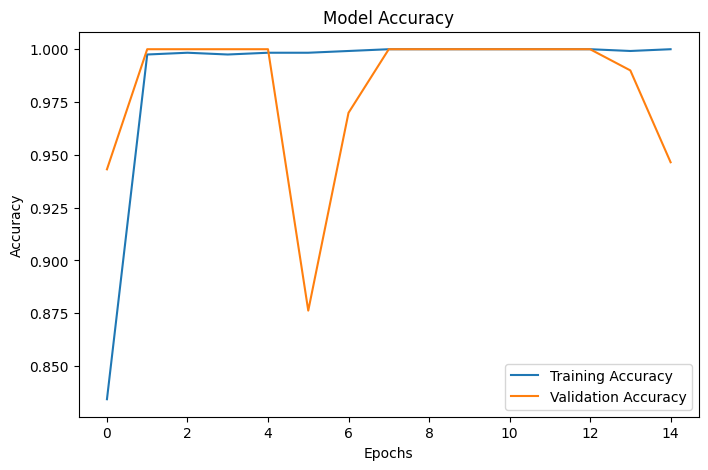

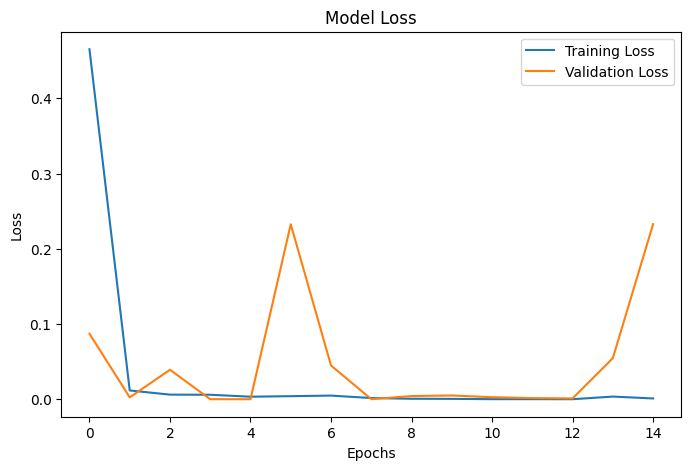

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# Paths
train_dir = r"/content/drive/MyDrive/CNN_Flask_Project/Dataset/Train"
test_dir = r"/content/drive/MyDrive/CNN_Flask_Project/Dataset/Test"

# Image settings
img_height = 128
img_width = 128
batch_size = 32
epochs = 15

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

# Save class names
class_indices = train_generator.class_indices
print("Class indices:", class_indices)

with open("class_names.json", "w") as f:
    json.dump(class_indices, f)

# Build CNN model
model = Sequential([
    Input(shape=(img_height, img_width, 3)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(train_generator.num_classes, activation="softmax")
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=epochs
)

# Save model
model.save("face_recognition_cnn.h5")
print("Model saved successfully as face_recognition_cnn.h5")

# Evaluate model
test_loss, test_accuracy = model.evaluate(test_generator)
print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# Predictions for report
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Reverse class mapping
label_map = {v: k for k, v in class_indices.items()}
target_names = [label_map[i] for i in range(len(label_map))]

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=target_names))

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
model.save("face_recognition_cnn.keras")

In [ ]:
!pip install flask pyngrok

In [ ]:
%cd /content/drive/MyDrive/CNN_Flask_Project/Dataset
!ls

/content/drive/MyDrive/CNN_Flask_Project/Dataset
app.py		  requirements.txt  templates  Train
class_names.json  static	    Test       train_model.py


In [ ]:
!cat /content/drive/MyDrive/CNN_Flask_Project/Dataset/class_names.json

{"Person 1": 0, "Person 2": 1, "Person 3": 2}

In [ ]:
!python app.py > flask.log 2>&1 &